<a href="https://colab.research.google.com/github/sampath6740/Automated-E-commerce-Sales-Data-Pipeline/blob/main/data_pre_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install apache-airflow

from airflow import DAG

from airflow.operators.python import PythonOperator

from datetime import datetime

import pandas as pd

import os

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 492.8/492.8 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.3/96.3 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.7/158.7 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.7/74.7 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 

2026-06-01T12:24:32.306706Z [warning  ] The `airflow.operators.python.PythonOperator` attribute is deprecated. Please use `'airflow.providers.standard.operators.python.PythonOperator'`. [py.warnings] category=DeprecatedImportWarning filename=/tmp/ipykernel_28596/1762561566.py lineno=5
2026-06-01T12:24:32.692170Z [info     ] NumExpr defaulting to 2 threads. [numexpr.utils] loc=utils.py:164


In [15]:
DATA_PATH = "/content/"

In [12]:
def validate_data():

    files = ["customer.csv", "order.csv", "payment.csv"]

In [16]:
files = ["customer.csv", "order.csv", "payment.csv"]
for file in files:

        path = os.path.join(DATA_PATH, file)

        if not os.path.exists(path):

            raise FileNotFoundError(f"{file} not found")

        df = pd.read_csv(path)

        print(f"\nChecking {file}")

        print(f"Rows: {len(df)}")

        print(f"Columns: {len(df.columns)}")

        print(f"Missing Values:\n{df.isnull().sum()}")


Checking customer.csv
Rows: 99441
Columns: 5
Missing Values:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Checking order.csv
Rows: 99441
Columns: 8
Missing Values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Checking payment.csv
Rows: 103886
Columns: 5
Missing Values:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64


In [17]:
def generate_report():

    customer = pd.read_csv(

        os.path.join(DATA_PATH, "customer.csv")

    )

    orders = pd.read_csv(

        os.path.join(DATA_PATH, "order.csv")

    )

    payment = pd.read_csv(

        os.path.join(DATA_PATH, "payment.csv")

    )

    report = {

        "Total Customers": len(customer),

        "Total Orders": len(orders),

        "Total Payments": len(payment)

    }

    print("\n===== PROJECT REPORT =====")

    for k, v in report.items():

        print(f"{k}: {v}")

with DAG(

    dag_id="ecommerce_pipeline",

    start_date=datetime(2025, 1, 1),

    schedule="@daily",

    catchup=False,

    tags=["ecommerce"],

) as dag:

    validate_task = PythonOperator(

        task_id="validate_data",

        python_callable=validate_data,

    )

    report_task = PythonOperator(

        task_id="generate_report",

        python_callable=generate_report,

    )

    validate_task >> report_task

analysis/results


In [18]:
import pandas as pd

In [19]:
customer = pd.read_csv("customer.csv")

orders = pd.read_csv("order.csv")

payment = pd.read_csv("payment.csv")

In [20]:
print("Total Customers:", len(customer))

print("Total Orders:", len(orders))

print("Total Payments:", len(payment))

Total Customers: 99441
Total Orders: 99441
Total Payments: 103886


In [21]:
print("\nOrder Status Distribution")

print(orders["order_status"].value_counts())


Order Status Distribution
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [22]:
print("\nOrder Status Distribution")

print(orders["order_status"].value_counts())


Order Status Distribution
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


visualizations


In [23]:
import matplotlib.pyplot as plt

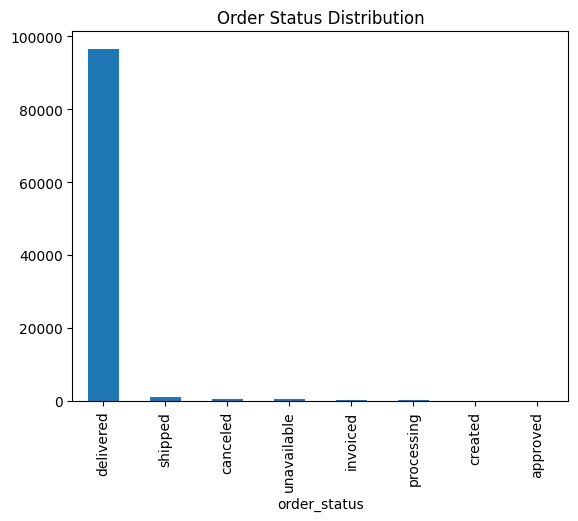

In [24]:
orders["order_status"].value_counts().plot(kind="bar")

plt.title("Order Status Distribution")

plt.show()

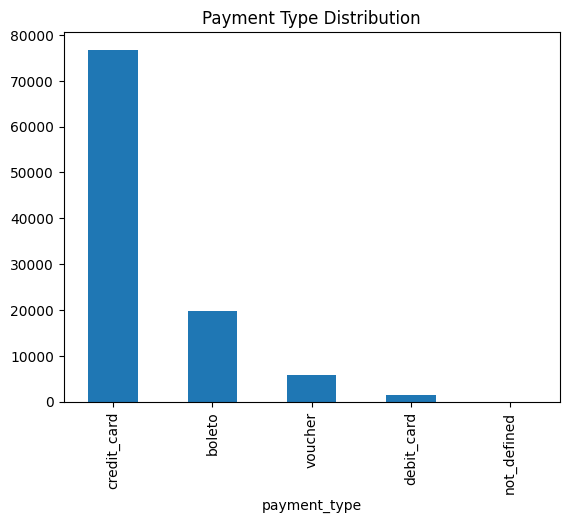

In [25]:
payment["payment_type"].value_counts().plot(kind="bar")

plt.title("Payment Type Distribution")

plt.show()

Business Analysis Report

In [26]:
import pandas as pd

In [27]:
customer = pd.read_csv("customer.csv")

orders = pd.read_csv("order.csv")

payment = pd.read_csv("payment.csv")

In [28]:
print("===== E-COMMERCE ANALYSIS REPORT =====\n")

===== E-COMMERCE ANALYSIS REPORT =====



In [29]:
print("Total Customers:", len(customer))

print("Total Orders:", len(orders))

print("Total Payments:", len(payment))

Total Customers: 99441
Total Orders: 99441
Total Payments: 103886


In [30]:
print("\nTop 5 Order Statuses")

print(orders['order_status'].value_counts().head())


Top 5 Order Statuses
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
Name: count, dtype: int64


In [31]:
print("\nTop 5 Payment Methods")

print(payment['payment_type'].value_counts().head())


Top 5 Payment Methods
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


In [32]:
delivery_rate = (

    orders['order_status'].value_counts()['delivered']

    / len(orders)

) * 100

print(f"\nDelivery Success Rate: {delivery_rate:.2f}%")


Delivery Success Rate: 97.02%
